In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score

# -----------------------------------------
# Load data
# -----------------------------------------
df = pd.read_csv("HOURLY_SOLAR_DATA_PREPROCESSED.csv")

# -----------------------------------------
# Sort by time (VERY IMPORTANT)
# -----------------------------------------
df = df.sort_values(
    by=["LAT", "LON", "month_sin", "hour_sin"]
).reset_index(drop=True)

# -----------------------------------------
# Features & target
# -----------------------------------------
X = df.drop(columns=["solar_kwh"])
y = df["solar_kwh"]

# -----------------------------------------
# Optional: log-transform target (recommended)
# -----------------------------------------
y_log = np.log1p(y)

# -----------------------------------------
# Time-based train-test split
# -----------------------------------------
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y_log.iloc[:split_idx], y_log.iloc[split_idx:]

# -----------------------------------------
# CatBoost model
# -----------------------------------------
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

# -----------------------------------------
# Train
# -----------------------------------------
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# -----------------------------------------
# Predict
# -----------------------------------------
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# -----------------------------------------
# Evaluation
# -----------------------------------------
rmse = mean_squared_error(y_true, y_pred, squared=False)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")


CatBoostError: catboost/libs/metrics/metric.cpp:6956: metric/loss-function RMSE do not allows nan value on target

In [3]:
print("Any NaNs in target?", y.isna().sum())
print("Any NaNs after log1p?", np.log1p(y).isna().sum())

Any NaNs in target? 720
Any NaNs after log1p? 720


In [4]:
# Check for any NaNs
print("Any NaNs in dataset?", df.isna().sum().sum())


Any NaNs in dataset? 1440


In [2]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------------------
# Load dataset
# -----------------------------------------
df = pd.read_csv("HOURLY_SOLAR_DATA_PREPROCESSED.csv")
print("✅ Dataset loaded:", df.shape)

# -----------------------------------------
# Optional: create lag/rolling features
# Uncomment if needed
# -----------------------------------------
# df["solar_kwh_lag1"] = df.groupby(["LAT", "LON"])["solar_kwh"].shift(1)
# df["solar_kwh_lag24"] = df.groupby(["LAT", "LON"])["solar_kwh"].shift(24)
# df["solar_kwh_roll3"] = df.groupby(["LAT", "LON"])["solar_kwh"].shift(1).rolling(3).mean()
# df["solar_kwh_roll24"] = df.groupby(["LAT", "LON"])["solar_kwh"].shift(1).rolling(24).mean()
# df = df.dropna().reset_index(drop=True)  # drop rows with NaNs from lags/rolls

# -----------------------------------------
# Sort by time (important for time-based split)
# -----------------------------------------
df = df.sort_values(by=["LAT", "LON", "month_sin", "hour_sin"]).reset_index(drop=True)

# -----------------------------------------
# Features & target
# -----------------------------------------
X = df.drop(columns=["solar_kwh"])
y = df["solar_kwh"]

# -----------------------------------------
# Clip negative values if any (safe)
# -----------------------------------------
y = y.clip(lower=0)

# -----------------------------------------
# Log-transform target (optional but recommended)
# -----------------------------------------
y_log = np.log1p(y)

# -----------------------------------------
# Time-based train-test split (80-20)
# -----------------------------------------
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y_log.iloc[:split_idx], y_log.iloc[split_idx:]

# -----------------------------------------
# CatBoost model
# -----------------------------------------
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

# -----------------------------------------
# Train
# -----------------------------------------
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# -----------------------------------------
# Predict
# -----------------------------------------
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # convert back to original scale
y_true = np.expm1(y_test)

# -----------------------------------------
# Evaluation
# -----------------------------------------
rmse = mean_squared_error(y_true, y_pred, squared=False)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("\n✅ Evaluation Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")

# -----------------------------------------
# Feature importance
# -----------------------------------------
fi = model.get_feature_importance(prettified=True)
print("\n✅ Feature Importance:")
print(fi)


✅ Dataset loaded: (1314720, 9)


CatBoostError: catboost/libs/metrics/metric.cpp:6956: metric/loss-function RMSE do not allows nan value on target

In [6]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------------------
# Load dataset
# -----------------------------------------
df = pd.read_csv("HOURLY_SOLAR_DATA_PREPROCESSED.csv")
print("✅ Dataset loaded:", df.shape)

# -----------------------------------------
# Ensure all numeric & fill NaNs with 0 (safe)
# -----------------------------------------
df = df.apply(pd.to_numeric, errors="coerce")
df = df.fillna(0)
print("Any NaNs after cleaning?", df.isna().sum().sum())

# -----------------------------------------
# Sort by time (important for time-based split)
# -----------------------------------------
df = df.sort_values(by=["LAT", "LON", "month_sin", "hour_sin"]).reset_index(drop=True)

# -----------------------------------------
# Features & target
# -----------------------------------------
X = df.drop(columns=["solar_kwh"])
y = df["solar_kwh"].clip(lower=0)  # clip tiny negatives just in case

# -----------------------------------------
# Optional: log-transform target (recommended)
# -----------------------------------------
y_log = np.log1p(y)

# -----------------------------------------
# Time-based train-test split (80-20)
# -----------------------------------------
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y_log.iloc[:split_idx], y_log.iloc[split_idx:]

# -----------------------------------------
# CatBoost model
# -----------------------------------------
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

# -----------------------------------------
# Train
# -----------------------------------------
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# -----------------------------------------
# Predict & invert log
# -----------------------------------------
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # convert back to original scale
y_true = np.expm1(y_test)

# -----------------------------------------
# Evaluation
# -----------------------------------------
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("\n✅ Evaluation Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")

# -----------------------------------------
# Feature importance
# -----------------------------------------
fi = model.get_feature_importance(prettified=True)
print("\n✅ Feature Importance:")
print(fi)


✅ Dataset loaded: (1314720, 9)
Any NaNs after cleaning? 0
0:	learn: 2.7203570	test: 2.7309540	best: 2.7309540 (0)	total: 65ms	remaining: 1m 4s
100:	learn: 0.0307427	test: 0.0452098	best: 0.0452098 (100)	total: 4.48s	remaining: 39.9s
200:	learn: 0.0225221	test: 0.0346160	best: 0.0346160 (200)	total: 8.82s	remaining: 35.1s
300:	learn: 0.0218303	test: 0.0340669	best: 0.0340669 (300)	total: 13.1s	remaining: 30.3s
400:	learn: 0.0214867	test: 0.0338969	best: 0.0338969 (400)	total: 17.4s	remaining: 26s
500:	learn: 0.0212736	test: 0.0337881	best: 0.0337881 (500)	total: 21.8s	remaining: 21.7s
600:	learn: 0.0211170	test: 0.0337225	best: 0.0337225 (600)	total: 25.9s	remaining: 17.2s
700:	learn: 0.0209583	test: 0.0336838	best: 0.0336838 (700)	total: 30.3s	remaining: 12.9s
800:	learn: 0.0207694	test: 0.0336437	best: 0.0336437 (800)	total: 34.3s	remaining: 8.52s
900:	learn: 0.0206103	test: 0.0336413	best: 0.0336340 (850)	total: 38.2s	remaining: 4.2s
999:	learn: 0.0204364	test: 0.0336433	best: 0.0336

In [9]:
# -----------------------------
# Imports
# -----------------------------
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import lightgbm as lgb

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv("HOURLY_SOLAR_DATA_PREPROCESSED.csv")

# -----------------------------
# Sort by time to avoid leakage
# -----------------------------
df = df.sort_values(by=["LAT", "LON", "month_sin", "hour_sin"]).reset_index(drop=True)

# -----------------------------
# Features and target
# -----------------------------
target = "solar_kwh"
X = df.drop(columns=[target])
y = df[target].clip(lower=0)  # remove tiny negatives if any

# Optional: log-transform target
y_log = np.log1p(y)

# -----------------------------
# Time-based train-test split (80-20)
# -----------------------------
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y_log.iloc[:split_idx], y_log.iloc[split_idx:]

# -----------------------------
# Categorical features (if any)
# -----------------------------
categorical_features = []  # e.g., ['month', 'hour'] if present

# -----------------------------
# Initialize LightGBM Regressor
# -----------------------------
model = LGBMRegressor(
    objective='regression',
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    n_estimators=1000,
    random_state=42
)

# -----------------------------
# Train the model with early stopping
# -----------------------------
model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    categorical_feature=categorical_features,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

# -----------------------------
# Predict & invert log
# -----------------------------
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# -----------------------------
# Evaluation
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("\n✅ LightGBM Evaluation Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")

# -----------------------------
# Feature importance
# -----------------------------
feature_importances = model.feature_importances_
plt.figure(figsize=(12,6))
plt.barh(X.columns, feature_importances)
plt.xlabel("Importance")
plt.title("LightGBM Feature Importance")
plt.show()


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 1051776, number of used features: 8
[LightGBM] [Info] Start training from score 2.796087
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.0270914	valid_0's l2: 0.000733945
[200]	valid_0's rmse: 0.0209744	valid_0's l2: 0.000439925
Early stopping, best iteration is:
[162]	valid_0's rmse: 0.0209389	valid_0's l2: 0.000438436


ValueError: Input contains NaN.

Training Solar Forecast Model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 584
[LightGBM] [Info] Number of data points in the train set: 1047624, number of used features: 8
[LightGBM] [Info] Start training from score 174.502330
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009755 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 584
[LightGBM] [Info] Number of data points in the train set: 1047624, number of used features: 8
[LightGBM] [Info] Start training from score 174.497404
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009824 seconds.
You can set `force_row_wise=true` to remove the

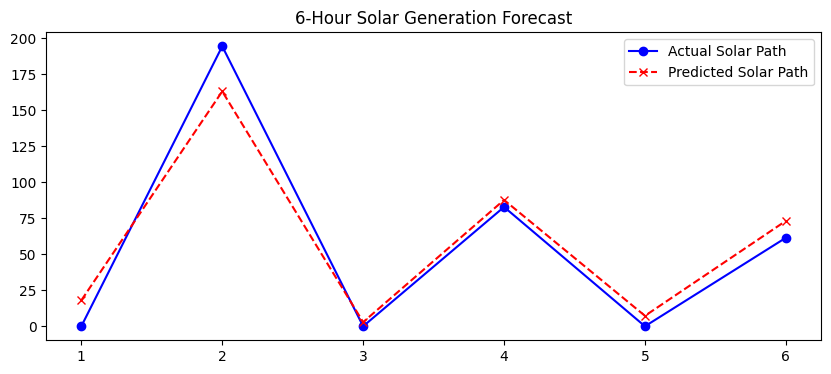

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD & CLEAN
# -----------------------------
df = pd.read_csv("HOURLY_SOLAR_DATA_PREPROCESSED.csv")

# CRITICAL: If you don't have a 'Year' column, use 'DAY' 
# We must sort so that time flows forward.
df = df.sort_values(by=['LAT', 'LON', 'DAY', 'hour_sin']).reset_index(drop=True)

# -----------------------------
# 2. PREVENT LEAKAGE (Drop the "Answers")
# -----------------------------
# We drop 'ALLSKY...' because we don't know the future sunlight at the time of prediction.
forbidden = ['ALLSKY_SFC_SW_DWN_HOURLY'] 
df = df.drop(columns=[c for c in forbidden if c in df.columns])

# -----------------------------
# 3. CREATE 6-HOUR TARGETS
# -----------------------------
target_cols = []
for h in range(1, 7):
    col = f'target_solar_{h}h'
    df[col] = df['solar_kwh'].shift(-h)
    target_cols.append(col)

# -----------------------------
# 4. METER-ONLY FEATURES (Lags)
# -----------------------------
# We only know what the solar production was in the PAST.
df['solar_lag_1h'] = df['solar_kwh'].shift(1)
df['solar_lag_24h'] = df['solar_kwh'].shift(24) # Yesterday's production

features = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 
    'LAT', 'LON', 'solar_lag_1h', 'solar_lag_24h'
]

# Clean up NaNs from shifting
df_clean = df.dropna(subset=features + target_cols).reset_index(drop=True)

X = df_clean[features]
Y = df_clean[target_cols]

# -----------------------------
# 5. TRAIN/TEST SPLIT
# -----------------------------
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
Y_train, Y_test = Y.iloc[:split], Y.iloc[split:]

# -----------------------------
# 6. MULTI-OUTPUT MODEL
# -----------------------------
model = MultiOutputRegressor(LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
))

print("Training Solar Forecast Model...")
model.fit(X_train, Y_train)

# -----------------------------
# 7. LEGIT EVALUATION
# -----------------------------
Y_pred = model.predict(X_test)

print("\n☀️ SOLAR FORECAST RESULTS (Next 6 Hours):")
for i in range(6):
    r2 = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
    mae = mean_absolute_error(Y_test.iloc[:, i], Y_pred[:, i])
    print(f"Hour +{i+1} -> R²: {r2:.4f} | MAE: {mae:.2f} kWh")

# -----------------------------
# 8. VISUALIZE
# -----------------------------
plt.figure(figsize=(10, 4))
plt.plot(range(1, 7), Y_test.iloc[100].values, 'bo-', label='Actual Solar Path')
plt.plot(range(1, 7), Y_pred[100], 'rx--', label='Predicted Solar Path')
plt.title("6-Hour Solar Generation Forecast")
plt.legend()
plt.show()

C:\Users\hiten\AppData\Local\Temp\ipykernel_36576\2741526252.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[['LAT', 'LON']] = scaler.fit_transform(X_train[['LAT', 'LON']])
C:\Users\hiten\AppData\Local\Temp\ipykernel_36576\2741526252.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[['LAT', 'LON']] = scaler.transform(X_test[['LAT', 'LON']])


Training Solar Forecast Model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011725 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1607
[LightGBM] [Info] Number of data points in the train set: 1037172, number of used features: 13
[LightGBM] [Info] Start training from score 174.341423
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014453 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1607
[LightGBM] [Info] Number of data points in the train set: 1037172, number of used features: 13
[LightGBM] [Info] Start training from score 174.388981
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011133 seconds.
You can set `force_row_wise=true` to remove

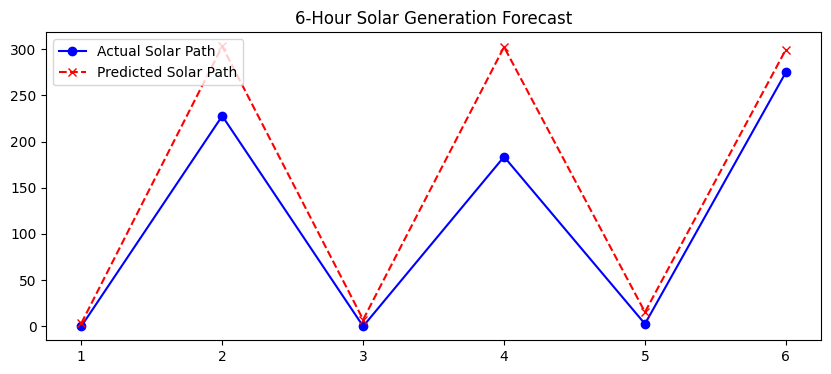

In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. LOAD & CLEAN
# -----------------------------
df = pd.read_csv("HOURLY_SOLAR_DATA_PREPROCESSED(2).csv")

df = df.sort_values(by=['LAT', 'LON', 'DAY', 'hour_sin']).reset_index(drop=True)

# -----------------------------
# 2. ADD is_day FEATURE
# ----------------------------

# -----------------------------
# 3. PREVENT LEAKAGE
# -----------------------------
forbidden = ['ALLSKY_SFC_SW_DWN_HOURLY']
df = df.drop(columns=[c for c in forbidden if c in df.columns])

# -----------------------------
# 4. CREATE 6-HOUR TARGETS
# -----------------------------
target_cols = []
for h in range(1, 7):
    col = f'target_solar_{h}h'
    df[col] = df['solar_kwh'].shift(-h)
    target_cols.append(col)

# -----------------------------
# 5. LAG FEATURES (ONLY PAST)
# -----------------------------
lags = [1, 3, 6, 24]
for lag in lags:
    df[f"solar_lag_{lag}h"] = df["solar_kwh"].shift(lag)

# -----------------------------
# 6. ROLLING FEATURES
# -----------------------------
df["solar_roll3h"] = df["solar_kwh"].rolling(3).mean().shift(1)
df["solar_roll24h"] = df["solar_kwh"].rolling(24).mean().shift(1)

# -----------------------------
# 7. FEATURES
# -----------------------------
features = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'LAT', 'LON', 'is_day',
    'solar_lag_1h', 'solar_lag_3h', 'solar_lag_6h', 'solar_lag_24h',
    'solar_roll3h', 'solar_roll24h'
]

# Clean NaNs
df_clean = df.dropna(subset=features + target_cols).reset_index(drop=True)

X = df_clean[features]
Y = df_clean[target_cols]

# -----------------------------
# 8. TRAIN/TEST SPLIT (BY TIME)
# -----------------------------
split = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
Y_train, Y_test = Y.iloc[:split], Y.iloc[split:]

# -----------------------------
# 9. SCALE LAT/LON (optional but good)
# -----------------------------
scaler = StandardScaler()
X_train[['LAT', 'LON']] = scaler.fit_transform(X_train[['LAT', 'LON']])
X_test[['LAT', 'LON']] = scaler.transform(X_test[['LAT', 'LON']])

# -----------------------------
# 10. MULTI-OUTPUT MODEL
# -----------------------------
model = MultiOutputRegressor(LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
))

print("Training Solar Forecast Model...")
model.fit(X_train, Y_train)

# -----------------------------
# 11. EVALUATION
# -----------------------------
Y_pred = model.predict(X_test)

print("\n☀️ SOLAR FORECAST RESULTS (Next 6 Hours):")
for i in range(6):
    r2 = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
    mae = mean_absolute_error(Y_test.iloc[:, i], Y_pred[:, i])
    print(f"Hour +{i+1} -> R²: {r2:.4f} | MAE: {mae:.2f} kWh")

avg_mae = mean_absolute_error(Y_test.values.flatten(), Y_pred.flatten())
print(f"\nAverage MAE (all 6 hours): {avg_mae:.2f} kWh")

# -----------------------------
# 12. VISUALIZE
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(range(1, 7), Y_test.iloc[100].values, 'bo-', label='Actual Solar Path')
plt.plot(range(1, 7), Y_pred[100], 'rx--', label='Predicted Solar Path')
plt.title("6-Hour Solar Generation Forecast")
plt.legend()
plt.show()


Training Solar Forecast Model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008659 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1607
[LightGBM] [Info] Number of data points in the train set: 1037172, number of used features: 13
[LightGBM] [Info] Start training from score 1788.116209
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014383 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1607
[LightGBM] [Info] Number of data points in the train set: 1037172, number of used features: 13
[LightGBM] [Info] Start training from score 1788.605217
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015685 seconds.
You can set `force_row_wise=true` to remo

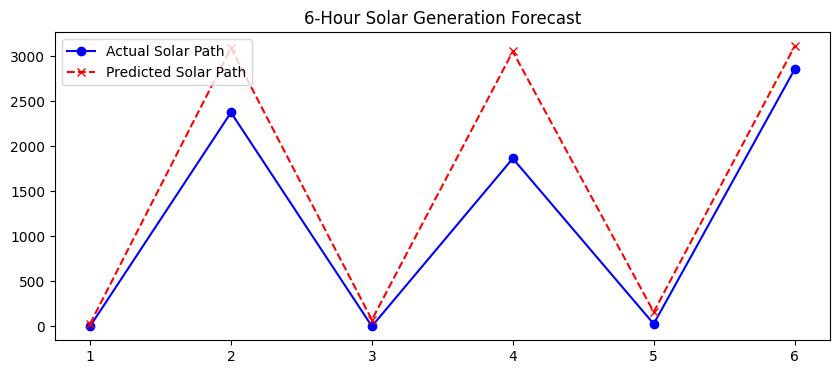

Model & scaler saved!


In [11]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. LOAD & CLEAN
# -----------------------------
df = pd.read_csv("HOURLY_SOLAR_DATA_PREPROCESSED(2).csv")

df = df.sort_values(by=['LAT', 'LON', 'DAY', 'hour_sin']).reset_index(drop=True)

# -----------------------------
# 2. ADD is_day FEATURE
# -----------------------------
df["is_day"] = (df["ALLSKY_SFC_SW_DWN_HOURLY"] > 0).astype(int)

# -----------------------------
# 3. PREVENT LEAKAGE
# -----------------------------
forbidden = ['ALLSKY_SFC_SW_DWN_HOURLY']
df = df.drop(columns=[c for c in forbidden if c in df.columns])

# -----------------------------
# 4. CREATE 6-HOUR TARGETS
# -----------------------------
target_cols = []
for h in range(1, 7):
    col = f'target_solar_{h}h'
    df[col] = df['solar_mwh'].shift(-h)
    target_cols.append(col)

# -----------------------------
# 5. LAG FEATURES (ONLY PAST)
# -----------------------------
lags = [1, 3, 6, 24]
for lag in lags:
    df[f"solar_lag_{lag}h"] = df["solar_mwh"].shift(lag)

# -----------------------------
# 6. ROLLING FEATURES
# -----------------------------
df["solar_roll3h"] = df["solar_mwh"].rolling(3).mean().shift(1)
df["solar_roll24h"] = df["solar_mwh"].rolling(24).mean().shift(1)

# -----------------------------
# 7. FEATURES
# -----------------------------
features = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'LAT', 'LON', 'is_day',
    'solar_lag_1h', 'solar_lag_3h', 'solar_lag_6h', 'solar_lag_24h',
    'solar_roll3h', 'solar_roll24h'
]

# Clean NaNs
df_clean = df.dropna(subset=features + target_cols).reset_index(drop=True)

X = df_clean[features].copy()
Y = df_clean[target_cols].copy()

# -----------------------------
# 8. TRAIN/TEST SPLIT (BY TIME)
# -----------------------------
split = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split].copy(), X.iloc[split:].copy()
Y_train, Y_test = Y.iloc[:split].copy(), Y.iloc[split:].copy()

# -----------------------------
# 9. SCALE LAT/LON (no warnings)
# -----------------------------
scaler = StandardScaler()

X_train.loc[:, ['LAT', 'LON']] = scaler.fit_transform(X_train[['LAT', 'LON']])
X_test.loc[:, ['LAT', 'LON']] = scaler.transform(X_test[['LAT', 'LON']])

# -----------------------------
# 10. MULTI-OUTPUT MODEL
# -----------------------------
model = MultiOutputRegressor(LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
))

print("Training Solar Forecast Model...")
model.fit(X_train, Y_train)

# -----------------------------
# 11. EVALUATION
# -----------------------------
Y_pred = model.predict(X_test)

print("\n☀️ SOLAR FORECAST RESULTS (Next 6 Hours):")
for i in range(6):
    r2 = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
    mae = mean_absolute_error(Y_test.iloc[:, i], Y_pred[:, i])
    print(f"Hour +{i+1} -> R²: {r2:.4f} | MAE: {mae:.2f} mWh")

avg_mae = mean_absolute_error(Y_test.values.flatten(), Y_pred.flatten())
print(f"\nAverage MAE (all 6 hours): {avg_mae:.2f} mWh")

# -----------------------------
# 12. VISUALIZE
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(range(1, 7), Y_test.iloc[100].values, 'bo-', label='Actual Solar Path')
plt.plot(range(1, 7), Y_pred[100], 'rx--', label='Predicted Solar Path')
plt.title("6-Hour Solar Generation Forecast")
plt.legend()
plt.show()

import joblib

joblib.dump(model, "solar_forecast_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model & scaler saved!")



Training Solar Forecast Model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010738 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2372
[LightGBM] [Info] Number of data points in the train set: 1037172, number of used features: 16
[LightGBM] [Info] Start training from score 1788.116209
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2372
[LightGBM] [Info] Number of data points in the train set: 1037172, number of used features: 16
[LightGBM] [Info] Start training from score 1788.605217
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016799 seconds.
You can set `force_row_wise=true` to remo

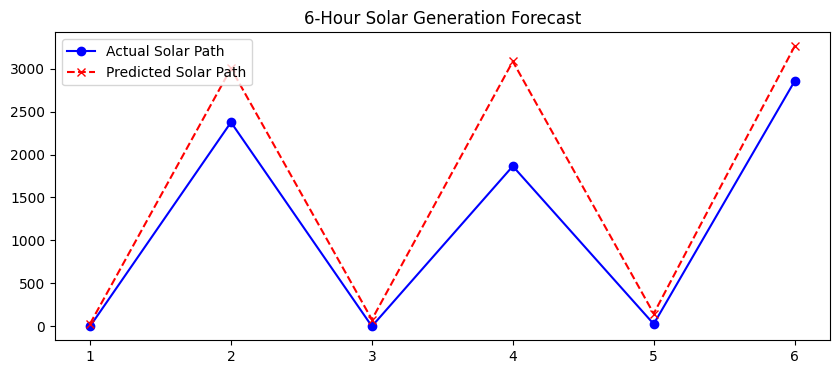

Model & scaler saved!


In [13]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. LOAD & CLEAN
# -----------------------------
df = pd.read_csv("HOURLY_SOLAR_DATA_PREPROCESSED(2).csv")

df = df.sort_values(by=['LAT', 'LON', 'DAY', 'hour_sin']).reset_index(drop=True)

# -----------------------------
# 2. ADD is_day FEATURE
# -----------------------------
df["is_day"] = (df["ALLSKY_SFC_SW_DWN_HOURLY"] > 0).astype(int)

# -----------------------------
# 3. PREVENT LEAKAGE
# -----------------------------
forbidden = ['ALLSKY_SFC_SW_DWN_HOURLY']
df = df.drop(columns=[c for c in forbidden if c in df.columns])

# -----------------------------
# 4. CREATE 6-HOUR TARGETS
# -----------------------------
target_cols = []
for h in range(1, 7):
    col = f'target_solar_{h}h'
    df[col] = df['solar_mwh'].shift(-h)
    target_cols.append(col)

# -----------------------------
# 5. LAG FEATURES (ONLY PAST)
# -----------------------------
lags = [1, 3, 6, 24]
for lag in lags:
    df[f"solar_lag_{lag}h"] = df["solar_mwh"].shift(lag)

# -----------------------------
# 6. ROLLING FEATURES
# -----------------------------
df["solar_roll3h"] = df["solar_mwh"].rolling(3).mean().shift(1)
df["solar_roll24h"] = df["solar_mwh"].rolling(24).mean().shift(1)

# -----------------------------
# 7. FEATURES
# -----------------------------
features = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'LAT', 'LON', 'is_day',
    'solar_lag_1h', 'solar_lag_3h', 'solar_lag_6h', 'solar_lag_24h',
    'solar_roll3h', 'solar_roll24h', 'ALLSKY_KT_HOURLY', 'T2M_HOURLY', 'WS10M_HOURLY'
]

# Clean NaNs
df_clean = df.dropna(subset=features + target_cols).reset_index(drop=True)

X = df_clean[features].copy()
Y = df_clean[target_cols].copy()

# -----------------------------
# 8. TRAIN/TEST SPLIT (BY TIME)
# -----------------------------
split = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split].copy(), X.iloc[split:].copy()
Y_train, Y_test = Y.iloc[:split].copy(), Y.iloc[split:].copy()

# -----------------------------
# 9. SCALE LAT/LON (no warnings)
# -----------------------------
scaler = StandardScaler()

X_train.loc[:, ['LAT', 'LON']] = scaler.fit_transform(X_train[['LAT', 'LON']])
X_test.loc[:, ['LAT', 'LON']] = scaler.transform(X_test[['LAT', 'LON']])

# -----------------------------
# 10. MULTI-OUTPUT MODEL
# -----------------------------
model = MultiOutputRegressor(LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
))

print("Training Solar Forecast Model...")
model.fit(X_train, Y_train)

# -----------------------------
# 11. EVALUATION
# -----------------------------
Y_pred = model.predict(X_test)

print("\n☀️ SOLAR FORECAST RESULTS (Next 6 Hours):")
for i in range(6):
    r2 = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
    mae = mean_absolute_error(Y_test.iloc[:, i], Y_pred[:, i])
    print(f"Hour +{i+1} -> R²: {r2:.4f} | MAE: {mae:.2f} mWh")

avg_mae = mean_absolute_error(Y_test.values.flatten(), Y_pred.flatten())
print(f"\nAverage MAE (all 6 hours): {avg_mae:.2f} mWh")

# -----------------------------
# 12. VISUALIZE
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(range(1, 7), Y_test.iloc[100].values, 'bo-', label='Actual Solar Path')
plt.plot(range(1, 7), Y_pred[100], 'rx--', label='Predicted Solar Path')
plt.title("6-Hour Solar Generation Forecast")
plt.legend()
plt.show()

import joblib

joblib.dump(model, "solar_forecast_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model & scaler saved!")


In [7]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv("HOURLY_SOLAR_DATA_PREPROCESSED(2).csv")

# -----------------------------
# 2. FEATURE ENGINEERING
# -----------------------------
df = df.sort_values(['LAT', 'LON', 'DAY', 'hour_sin']).reset_index(drop=True)

# Drop leak column
if "ALLSKY_SFC_SW_DWN_HOURLY" in df.columns:
    df.drop(columns=["ALLSKY_SFC_SW_DWN_HOURLY"], inplace=True)

# Create targets
target_cols = []
for h in range(1, 7):
    col = f'target_solar_{h}h'
    df[col] = df['solar_kwh'].shift(-h)
    target_cols.append(col)

# Lag features
lags = [1, 3, 6, 24]
for lag in lags:
    df[f"solar_lag_{lag}h"] = df["solar_kwh"].shift(lag)

df["solar_roll3h"] = df["solar_kwh"].rolling(3).mean().shift(1)
df["solar_roll24h"] = df["solar_kwh"].rolling(24).mean().shift(1)

features = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'LAT', 'LON', 'is_day',
    'solar_lag_1h', 'solar_lag_3h', 'solar_lag_6h', 'solar_lag_24h',
    'solar_roll3h', 'solar_roll24h'
]

# Clean NaNs
df_clean = df.dropna(subset=features + target_cols).reset_index(drop=True)

X = df_clean[features].copy()
Y = df_clean[target_cols].copy()

# -----------------------------
# 3. TRAIN/TEST SPLIT
# -----------------------------
split = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split].copy(), X.iloc[split:].copy()
Y_train, Y_test = Y.iloc[:split].copy(), Y.iloc[split:].copy()

# -----------------------------
# 4. SCALE LAT/LON
# -----------------------------
scaler = StandardScaler()
X_train.loc[:, ['LAT', 'LON']] = scaler.fit_transform(X_train[['LAT', 'LON']])
X_test.loc[:, ['LAT', 'LON']] = scaler.transform(X_test[['LAT', 'LON']])

# -----------------------------
# 5. TRAIN ONE MODEL PER HORIZON
# -----------------------------
models = {}

for i in range(6):
    horizon = i + 1
    y_train = Y_train.iloc[:, i]
    
    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function='MAE',
        random_seed=42,
        verbose=False
    )
    
    print(f"Training Horizon +{horizon}h...")
    model.fit(X_train, y_train)
    models[horizon] = model

# -----------------------------
# 6. PREDICTION & EVALUATION
# -----------------------------
print("\n☀️ CATBOOST SOLAR FORECAST RESULTS (Next 6 Hours):")

preds = []
for i in range(6):
    horizon = i + 1
    y_pred = models[horizon].predict(X_test)
    preds.append(y_pred)

preds = np.vstack(preds).T  # shape -> (n_samples, 6)

for i in range(6):
    r2 = r2_score(Y_test.iloc[:, i], preds[:, i])
    mae = mean_absolute_error(Y_test.iloc[:, i], preds[:, i])
    print(f"Hour +{i+1} -> R²: {r2:.4f} | MAE: {mae:.2f} kWh")

avg_mae = mean_absolute_error(Y_test.values.flatten(), preds.flatten())
print(f"\nAverage MAE (all 6 hours): {avg_mae:.2f} kWh")


Training Horizon +1h...
Training Horizon +2h...
Training Horizon +3h...
Training Horizon +4h...
Training Horizon +5h...
Training Horizon +6h...

☀️ CATBOOST SOLAR FORECAST RESULTS (Next 6 Hours):
Hour +1 -> R²: 0.9111 | MAE: 32.75 kWh
Hour +2 -> R²: 0.8824 | MAE: 36.28 kWh
Hour +3 -> R²: 0.8285 | MAE: 42.49 kWh
Hour +4 -> R²: 0.7768 | MAE: 47.06 kWh
Hour +5 -> R²: 0.7163 | MAE: 53.63 kWh
Hour +6 -> R²: 0.6780 | MAE: 57.17 kWh

Average MAE (all 6 hours): 44.90 kWh
